# 第2讲 课程代码案例：数据高阶可视化 × AI 辅助表达

> 课程：Python 进阶 | 教师：孙青 / 欧阳元新 | 平台：CloudStudio + CodeBuddy
>
> **AI 角色定位 = 设计顾问**：图表方案生成 / 视觉审查 / 结论修正
>
> **数据集**：NASA GISTEMP v4 全球气温距平（1880-2024）

## Part 1：Matplotlib 进阶与图表决策

**受众**：已掌握基础绑图，需要进阶的学生

**前置条件**：第1讲完成，已熟悉 Pandas DataFrame 操作

**学习目标**：
1. 掌握图表决策树——不同数据特征对应的最佳图表类型
2. 掌握 Matplotlib 进阶操作：fill_between / 多子图 / 系统化美化
3. 学会让 AI 推荐图表类型

### 1.1 环境配置与数据加载

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# 中文显示配置
plt.rcParams.update({
    'font.sans-serif': ['Arial Unicode MS', 'SimHei', 'DejaVu Sans'],
    'axes.unicode_minus': False,
    'figure.dpi': 100,
    'savefig.dpi': 300,
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'figure.figsize': (10, 6),
})

# 加载 NASA GISTEMP 数据
df = pd.read_csv('global_temperature.csv')
print(f"数据形状: {df.shape}")
print(f"列名: {list(df.columns)}")
print(f"数据源: {df['Source'].unique()}")
print(f"年份范围: {df['Year'].min()}-{df['Year'].max()}")
print()
print(df.head())

数据形状: (3480, 4)
列名: ['Source', 'Year', 'Month', 'Mean']
数据源: ['GISTEMP' 'GCAG']
年份范围: 1880-2024

    Source  Year  Month    Mean
0  GISTEMP  1880      1 -0.1900
1     GCAG  1880      1 -0.3816
2  GISTEMP  1880      2 -0.2500
3     GCAG  1880      2 -0.4331
4  GISTEMP  1880      3 -0.1000


### 1.2 数据预处理

In [2]:
# 筛选 GISTEMP 数据源
gistemp = df[df['Source'] == 'GISTEMP'].copy()

# 年度数据（Month == 0 表示年均值，若无则自行计算）
if 0 in gistemp['Month'].values:
    annual = gistemp[gistemp['Month'] == 0][['Year', 'Mean']].set_index('Year')['Mean']
else:
    annual = gistemp[gistemp['Month'].between(1, 12)].groupby('Year')['Mean'].mean()

# 月度数据
monthly = gistemp[gistemp['Month'].between(1, 12)].copy()

print(f"年度数据: {len(annual)} 年 ({annual.index.min()}-{annual.index.max()})")
print(f"月度数据: {len(monthly)} 条")
print(f"年度距平范围: [{annual.min():.3f}, {annual.max():.3f}] °C")

年度数据: 145 年 (1880-2024)
月度数据: 1740 条
年度距平范围: [-0.488, 1.286] °C


### 1.3 折线图进阶：正负距平分色填充

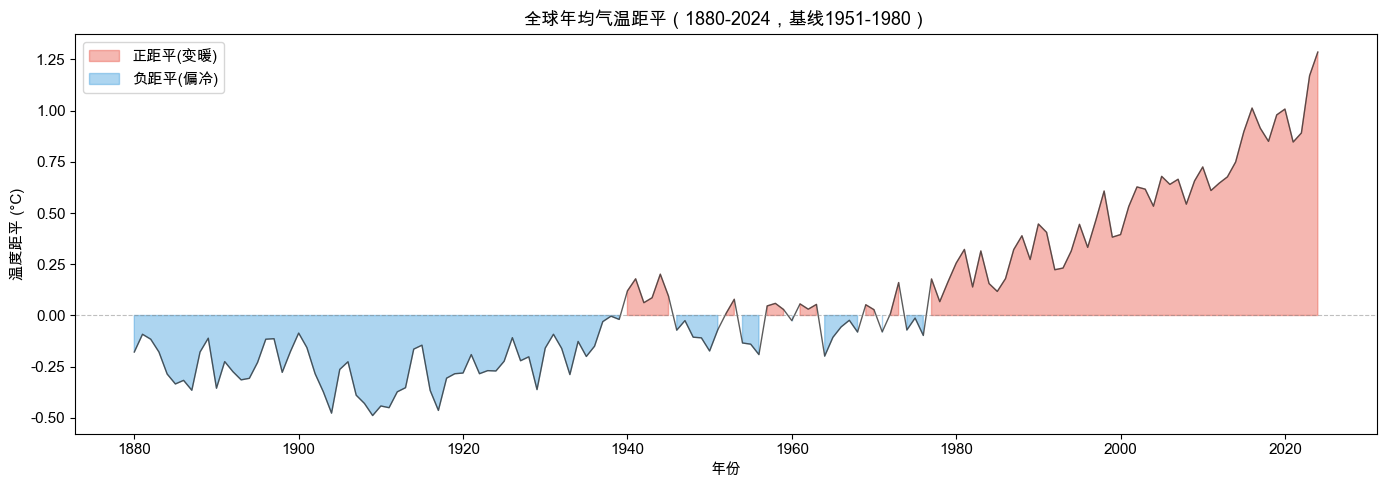

In [3]:
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(annual.index, annual.values, color='#333333', linewidth=1, alpha=0.8)
ax.axhline(0, color='gray', linestyle='--', alpha=0.5, linewidth=0.8)

# fill_between：正距平红色，负距平蓝色
ax.fill_between(annual.index, annual.values, 0,
                where=(annual.values > 0), color='#E74C3C', alpha=0.4, label='正距平(变暖)')
ax.fill_between(annual.index, annual.values, 0,
                where=(annual.values <= 0), color='#3498DB', alpha=0.4, label='负距平(偏冷)')

ax.set_title('全球年均气温距平（1880-2024，基线1951-1980）')
ax.set_xlabel('年份')
ax.set_ylabel('温度距平 (°C)')
ax.legend(loc='upper left')
plt.tight_layout()
plt.savefig('output/trend_fillbetween.png', dpi=300, bbox_inches='tight')
plt.show()

### 1.4 柱状图：年代均值对比

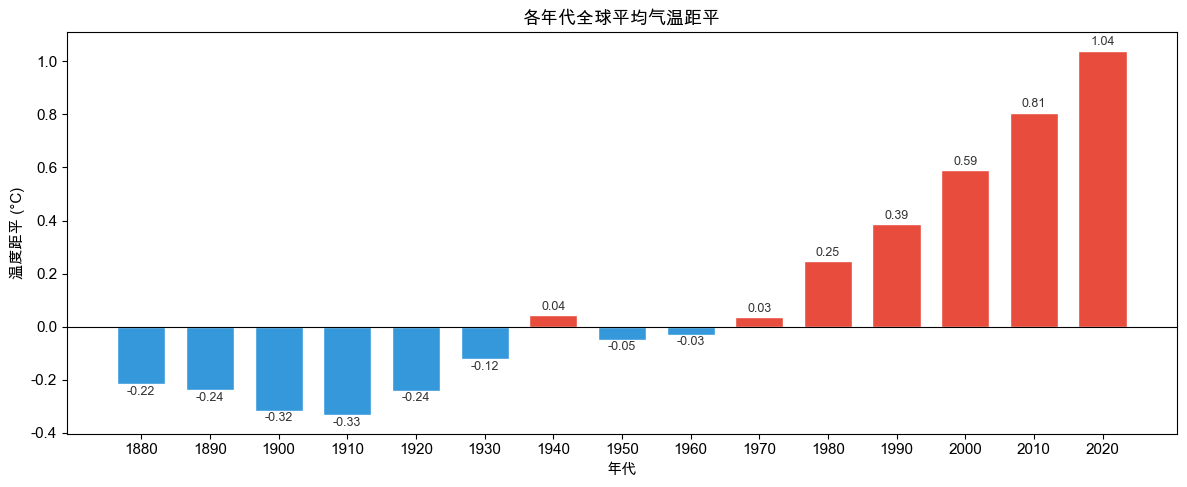

In [4]:
# 按年代分组
decades = annual.groupby(annual.index // 10 * 10).mean()

fig, ax = plt.subplots(figsize=(12, 5))
colors = ['#3498DB' if v < 0 else '#E74C3C' for v in decades.values]
bars = ax.bar(decades.index.astype(str), decades.values, color=colors, width=0.7, edgecolor='white')
ax.axhline(0, color='black', linewidth=0.8)

# 数值标签
for bar, v in zip(bars, decades.values):
    y_pos = v + 0.02 if v >= 0 else v - 0.04
    ax.text(bar.get_x() + bar.get_width()/2, y_pos, f'{v:.2f}',
            ha='center', fontsize=9, color='#333')

ax.set_title('各年代全球平均气温距平')
ax.set_xlabel('年代')
ax.set_ylabel('温度距平 (°C)')
plt.tight_layout()
plt.savefig('output/decade_bar.png', dpi=300, bbox_inches='tight')
plt.show()

### 1.5 多子图布局：四个季节的趋势

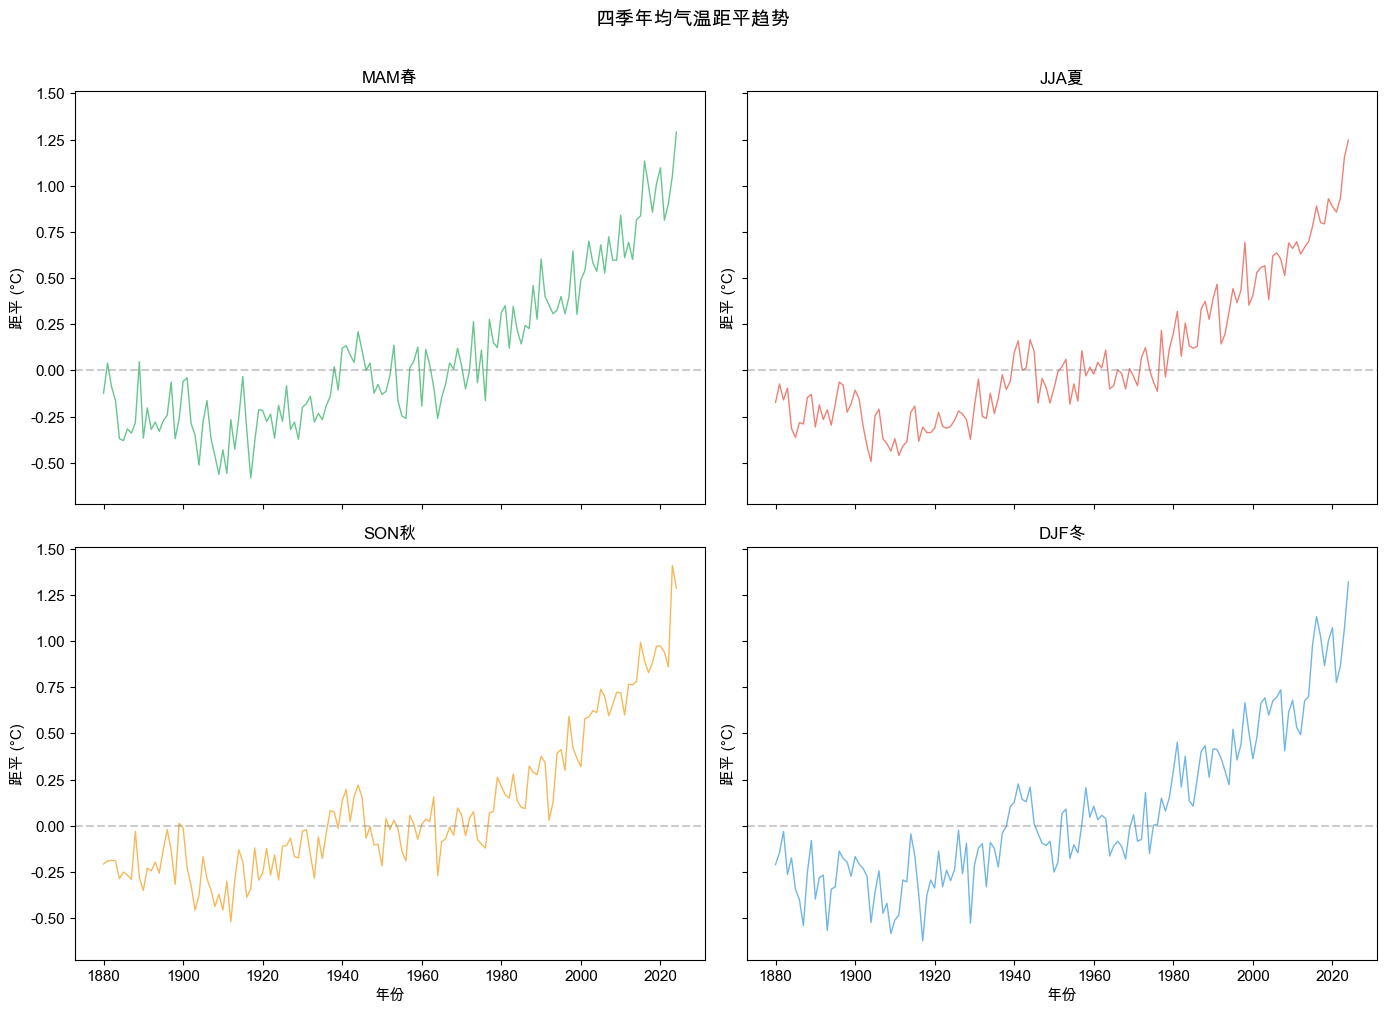

In [5]:
# 划分四季
season_map = {12: 'DJF冬', 1: 'DJF冬', 2: 'DJF冬',
              3: 'MAM春', 4: 'MAM春', 5: 'MAM春',
              6: 'JJA夏', 7: 'JJA夏', 8: 'JJA夏',
              9: 'SON秋', 10: 'SON秋', 11: 'SON秋'}
monthly['Season'] = monthly['Month'].map(season_map)
seasonal_annual = monthly.groupby(['Year', 'Season'])['Mean'].mean().reset_index()

fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharex=True, sharey=True)
seasons = ['MAM春', 'JJA夏', 'SON秋', 'DJF冬']
colors_s = ['#27AE60', '#E74C3C', '#F39C12', '#3498DB']

for ax, season, color in zip(axes.flat, seasons, colors_s):
    data = seasonal_annual[seasonal_annual['Season'] == season]
    ax.plot(data['Year'], data['Mean'], color=color, linewidth=1, alpha=0.7)
    ax.axhline(0, color='gray', linestyle='--', alpha=0.4)
    ax.set_title(season, fontsize=12)
    ax.set_ylabel('距平 (°C)')

axes[1, 0].set_xlabel('年份')
axes[1, 1].set_xlabel('年份')
plt.suptitle('四季年均气温距平趋势', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('output/seasons_subplot.png', dpi=300, bbox_inches='tight')
plt.show()

### 1.6 AI 协作：让 AI 推荐图表类型

**课堂练习 Prompt 示例**：

```
我有一个全球气温距平数据集（1880-2024，月度+年度，两个数据源）。
我想展示：1)长期变暖趋势 2)近30年加速 3)各月差异 4)两源一致性
请为每个目标推荐图表类型并说明原因。
```

> AI 角色 = 设计顾问：先推荐方案，再由你选择和决策

## Part 2：Seaborn 高阶统计可视化

**受众**：需要快速探索多维数据的学生

**前置条件**：Part 1 完成

**学习目标**：
1. 掌握 Seaborn 高阶图表：热力图 / 小提琴图 / 分面图
2. 理解 Seaborn vs Matplotlib 的定位差异
3. 学会让 AI 给出多方案对比

### 2.1 热力图：月份 × 年代的气温矩阵

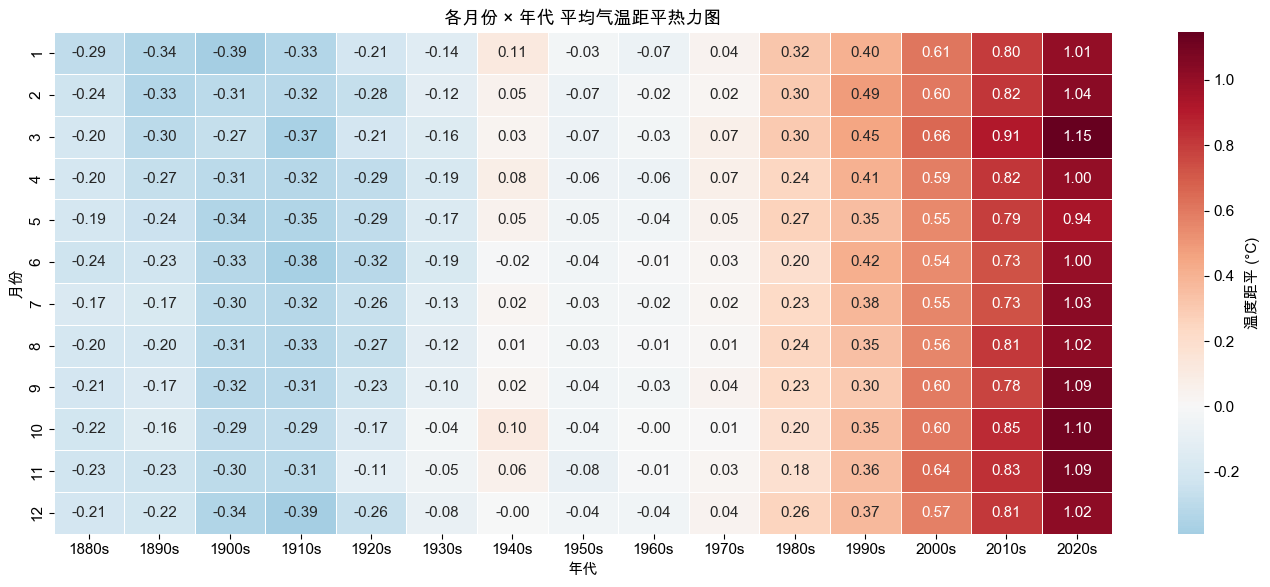

In [6]:
# 构造月份×年代的透视表
monthly['Decade'] = (monthly['Year'] // 10 * 10).astype(str) + 's'
pivot = monthly.pivot_table(values='Mean', index='Month', columns='Decade', aggfunc='mean')

fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(pivot, cmap='RdBu_r', center=0, annot=True, fmt='.2f',
            linewidths=0.5, ax=ax, cbar_kws={'label': '温度距平 (°C)'})
ax.set_title('各月份 × 年代 平均气温距平热力图')
ax.set_xlabel('年代')
ax.set_ylabel('月份')
plt.tight_layout()
plt.savefig('output/heatmap_month_decade.png', dpi=300, bbox_inches='tight')
plt.show()

### 2.2 小提琴图：两个时期的分布对比

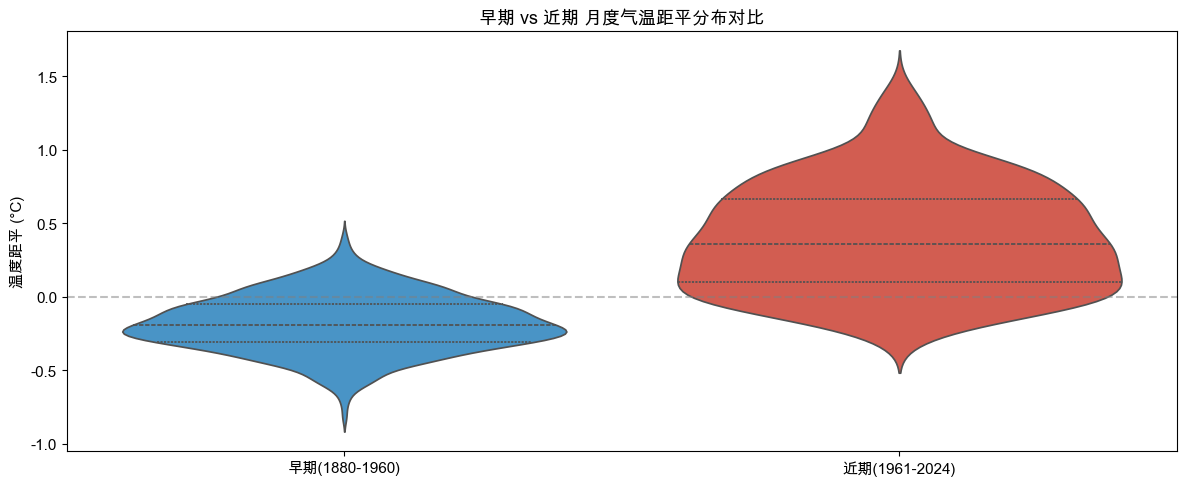

早期(1880-1960): 均值=-0.182, 中位数=-0.190, std=0.191
近期(1961-2024): 均值=0.399, 中位数=0.360, std=0.370


In [7]:
# 划分两个时期
monthly['Period'] = monthly['Year'].apply(
    lambda y: '早期(1880-1960)' if y <= 1960 else '近期(1961-2024)')

fig, ax = plt.subplots(figsize=(12, 5))
sns.violinplot(data=monthly, x='Period', y='Mean',
               palette=['#3498DB', '#E74C3C'], inner='quartile', ax=ax)
ax.axhline(0, color='gray', linestyle='--', alpha=0.5)
ax.set_title('早期 vs 近期 月度气温距平分布对比')
ax.set_xlabel('')
ax.set_ylabel('温度距平 (°C)')
plt.tight_layout()
plt.savefig('output/violin_periods.png', dpi=300, bbox_inches='tight')
plt.show()

# 统计摘要
for period in ['早期(1880-1960)', '近期(1961-2024)']:
    data = monthly[monthly['Period'] == period]['Mean']
    print(f"{period}: 均值={data.mean():.3f}, 中位数={data.median():.3f}, std={data.std():.3f}")

### 2.3 FacetGrid 分面图：四季趋势+回归线

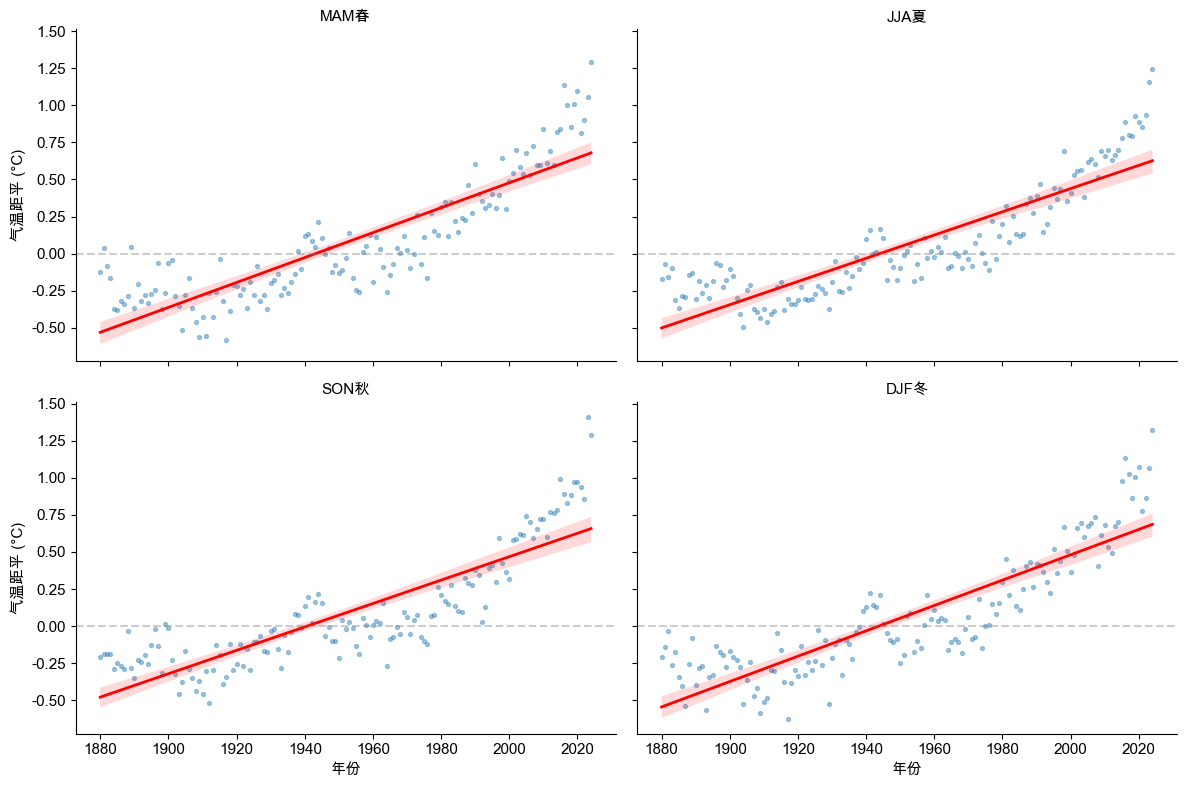

In [8]:
g = sns.FacetGrid(seasonal_annual, col='Season', col_wrap=2,
                  height=4, aspect=1.5, col_order=seasons)
g.map_dataframe(sns.regplot, x='Year', y='Mean',
                scatter_kws={'s': 8, 'alpha': 0.4},
                line_kws={'color': 'red', 'linewidth': 2})
g.set_titles('{col_name}')
g.set_axis_labels('年份', '气温距平 (°C)')

# 添加零线
for ax in g.axes.flat:
    ax.axhline(0, color='gray', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig('output/facetgrid_seasons.png', dpi=300, bbox_inches='tight')
plt.show()

### 2.4 AI 协作：Seaborn 方案对比

**课堂练习 Prompt**：

```
我想对比全球气温数据中四个季节的变暖趋势差异。
数据是长格式：Year / Season / Mean_Anomaly
请给出 3 种 Seaborn 方案，说明各自优缺点。
```

> 让 AI 给出多方案 → 你选择最合适的 → AI 生成代码

## Part 3：科研论文级图表

**受众**：需要在毕业论文或学术会议中使用图表的学生

**前置条件**：Part 1-2 完成

**学习目标**：
1. 掌握误差棒图 / 置信区间 / 双轴图 / 统计标注
2. 理解 Nature/Science 期刊的图表规范
3. 掌握色盲友好配色方案（Wong 2011）

### 3.1 误差棒图：年代均值±标准差

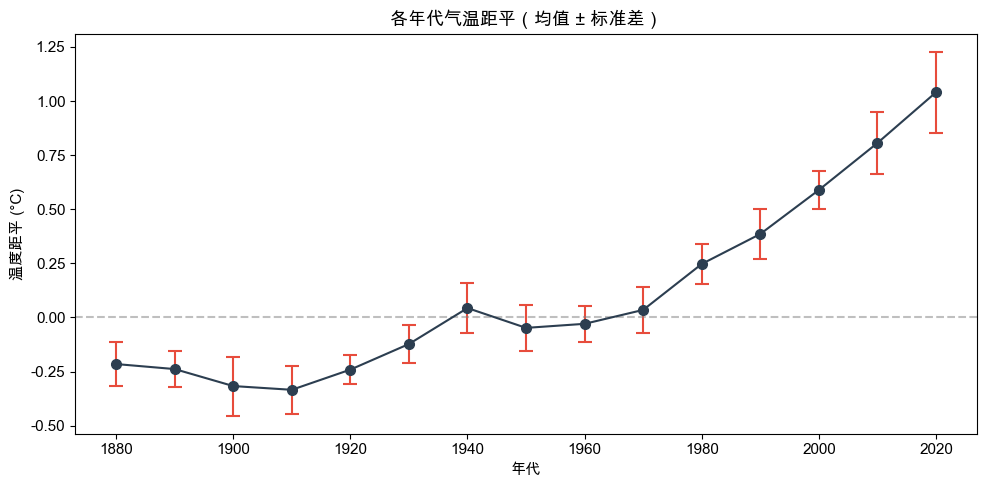

In [9]:
# 各年代的均值和标准差
decade_stats = annual.groupby(annual.index // 10 * 10).agg(['mean', 'std'])

fig, ax = plt.subplots(figsize=(10, 5))
ax.errorbar(decade_stats.index, decade_stats['mean'], yerr=decade_stats['std'],
            fmt='o-', capsize=5, capthick=1.5,
            color='#2C3E50', ecolor='#E74C3C', markersize=7, linewidth=1.5)
ax.axhline(0, color='gray', linestyle='--', alpha=0.5)
ax.set_title('各年代气温距平（均值 ± 标准差）')
ax.set_xlabel('年代')
ax.set_ylabel('温度距平 (°C)')
plt.tight_layout()
plt.savefig('output/errorbar_decades.png', dpi=300, bbox_inches='tight')
plt.show()

### 3.2 置信区间：10年滑动平均 + 95% CI

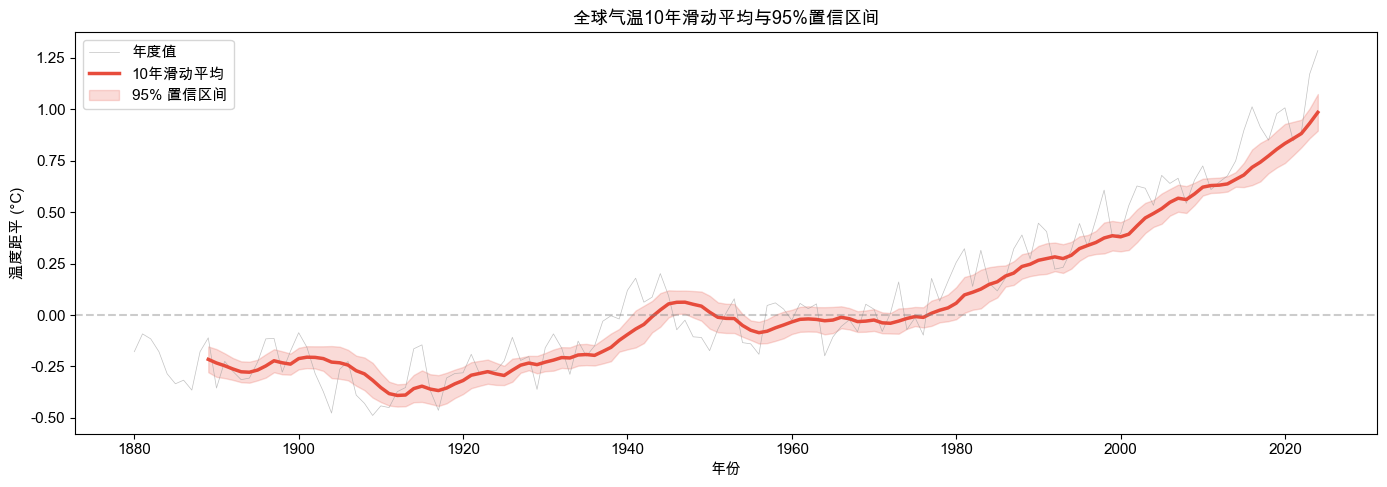

In [10]:
window = 10
rolling_mean = annual.rolling(window).mean()
rolling_std = annual.rolling(window).std()
ci_upper = rolling_mean + 1.96 * rolling_std / np.sqrt(window)
ci_lower = rolling_mean - 1.96 * rolling_std / np.sqrt(window)

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(annual.index, annual.values, color='#999', linewidth=0.5, alpha=0.6, label='年度值')
ax.plot(annual.index, rolling_mean, color='#E74C3C', linewidth=2.5, label='10年滑动平均')
ax.fill_between(annual.index, ci_lower, ci_upper, alpha=0.2, color='#E74C3C', label='95% 置信区间')
ax.axhline(0, color='gray', linestyle='--', alpha=0.4)
ax.set_title('全球气温10年滑动平均与95%置信区间')
ax.set_xlabel('年份')
ax.set_ylabel('温度距平 (°C)')
ax.legend(loc='upper left')
plt.tight_layout()
plt.savefig('output/ci_rolling.png', dpi=300, bbox_inches='tight')
plt.show()

### 3.3 统计标注：显著性检验

In [11]:
# t 检验：早期 vs 近期
early = annual[(annual.index >= 1880) & (annual.index <= 1920)].values
recent = annual[(annual.index >= 1990) & (annual.index <= 2024)].values
t_stat, p_value = stats.ttest_ind(recent, early)

print(f"=== 独立样本 t 检验 ===")
print(f"早期(1880-1920): n={len(early)}, mean={early.mean():.4f}")
print(f"近期(1990-2024): n={len(recent)}, mean={recent.mean():.4f}")
print(f"t 统计量: {t_stat:.4f}")
print(f"p 值: {p_value:.2e}")
significance = '***' if p_value < 0.001 else '**' if p_value < 0.01 else '*' if p_value < 0.05 else 'ns'
print(f"显著性: {significance}")

=== 独立样本 t 检验 ===
早期(1880-1920): n=41, mean=-0.2766
近期(1990-2024): n=35, mean=0.6573
t 统计量: 20.9043
p 值: 8.90e-33
显著性: ***


### 3.4 发表级完整示例（Nature 标准）

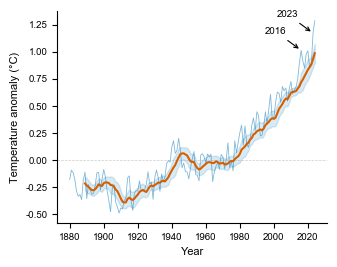

已保存 PDF + PNG（Nature 单栏标准: 3.5×2.8 inch, 300dpi）


In [12]:
# Wong 2011 色盲友好配色
COLORS = {
    'blue': '#0072B2', 'orange': '#E69F00', 'green': '#009E73',
    'pink': '#CC79A7', 'lightblue': '#56B4E9', 'red': '#D55E00'
}

fig, ax = plt.subplots(figsize=(3.5, 2.8))  # Nature 单栏宽度

# 主折线 + 滑动平均
ax.plot(annual.index, annual.values, color=COLORS['blue'], linewidth=0.6, alpha=0.5)
ax.plot(annual.index, rolling_mean, color=COLORS['red'], linewidth=1.5)
ax.fill_between(annual.index, ci_lower, ci_upper, alpha=0.15, color=COLORS['blue'])

# 标注最暖年
for year_mark in [2016, 2023]:
    if year_mark in annual.index:
        val = annual[year_mark]
        ax.annotate(f'{year_mark}', xy=(year_mark, val),
                    xytext=(year_mark-15, val+0.15),
                    fontsize=7, ha='center',
                    arrowprops=dict(arrowstyle='->', color='black', lw=0.8))

# 发表级排版
ax.set_xlabel('Year', fontsize=8)
ax.set_ylabel('Temperature anomaly (°C)', fontsize=8)
ax.tick_params(labelsize=7)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.axhline(0, color='gray', linestyle='--', linewidth=0.5, alpha=0.4)

plt.tight_layout()
plt.savefig('output/fig_nature.pdf', dpi=300, bbox_inches='tight')
plt.savefig('output/fig_nature.png', dpi=300, bbox_inches='tight')
plt.show()
print("已保存 PDF + PNG（Nature 单栏标准: 3.5×2.8 inch, 300dpi）")

### 3.5 科研图表 Checklist

| 检查项 | 要求 |
|--------|------|
| 分辨率 | >= 300 dpi |
| 字号 | 正文 8-10pt，标题 10-12pt |
| 背景 | 白底，无灰色网格 |
| 边框 | 去掉顶部和右侧（`sns.despine()`） |
| 配色 | 色盲友好（Wong 2011 / viridis） |
| 轴标签 | 含单位 |
| 图例 | 不遮挡数据 |
| 输出 | PDF（矢量）+ PNG（位图备用） |

## Part 4：AI 辅助可视化三轮迭代

**受众**：所有学生

**前置条件**：Part 1-3 完成

**学习目标**：
1. 掌握三轮迭代法：氛围→约束→Inline Edit
2. 学会让 AI 做视觉审查
3. 理解 AI 设计顾问的使用边界

### 4.1 三轮迭代法演示

**Round 1（氛围层）**：
```
用气温距平数据画一张展示全球变暖趋势的图，科学感风格
```

**Round 2（约束层）**：
```
保持整体结构，按以下要求优化：
1. 正距平填充红色，负距平填充蓝色
2. 加 10 年滑动平均黑色虚线
3. 标注最暖年 2016 和 2023
4. 中文标题和标签，300dpi
```

**Round 3（Inline Edit 微调）**：
```
Cmd+K → "x轴标签每20年显示一次；图例移到左上角；填充透明度改为0.3"
```

### 4.2 AI 视觉审查：常见问题

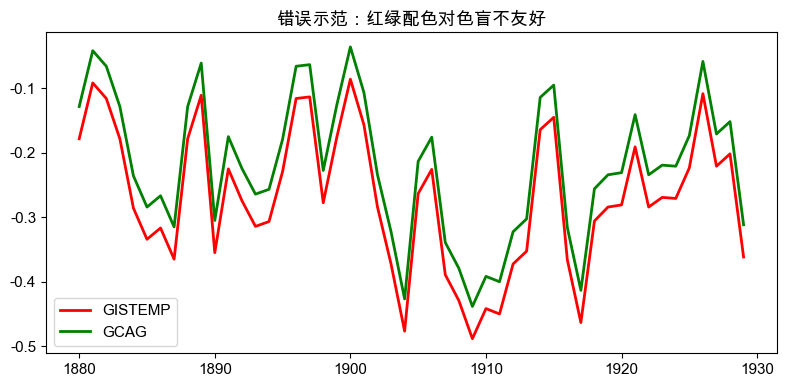

=== AI 视觉审查 Prompt ===
请审查这张图表，从以下维度指出问题：
1. 配色是否色盲友好？
2. 轴标签是否含单位？
3. 分辨率是否满足发表要求？
4. 图例位置是否遮挡数据？


In [13]:
# 演示：故意犯一些常见错误，然后让 AI 审查
fig, ax = plt.subplots(figsize=(8, 4))

# 错误示范：红绿配色（对色盲不友好）
ax.plot(annual.index[:50], annual.values[:50], color='red', linewidth=2, label='GISTEMP')
ax.plot(annual.index[:50], annual.values[:50] + 0.05, color='green', linewidth=2, label='GCAG')
ax.set_title('错误示范：红绿配色对色盲不友好')
ax.legend()
plt.tight_layout()
plt.show()

review_prompt = (
    "=== AI 视觉审查 Prompt ===\n"
    "请审查这张图表，从以下维度指出问题：\n"
    "1. 配色是否色盲友好？\n"
    "2. 轴标签是否含单位？\n"
    "3. 分辨率是否满足发表要求？\n"
    "4. 图例位置是否遮挡数据？"
)
print(review_prompt)